In [75]:
import pandas as pd


In [76]:
raw = pd.read_csv('https://hilpisch.com/pyalgo_eikon_eod_data.csv',
                            index_col=0, parse_dates=True).dropna()

In [77]:
data = pd.DataFrame(raw['EUR='])

In [78]:
data.rename(columns={'EUR=': 'price'}, inplace=True) 

In [79]:
data['SMA1'] = data['price'].rolling(42).mean()

In [80]:
data['SMA2'] = data['price'].rolling(252).mean() 

In [81]:
data.tail()

,price,SMA1,SMA2
Date,,,
2019-12-24,1.1087,1.107698,1.119630
2019-12-26,1.1096,1.107740,1.119529
2019-12-27,1.1175,1.107924,1.119428
2019-12-30,1.1197,1.108131,1.119333
2019-12-31,1.1210,1.108279,1.119231


In [82]:
%matplotlib inline

In [83]:
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.family'] = 'serif'


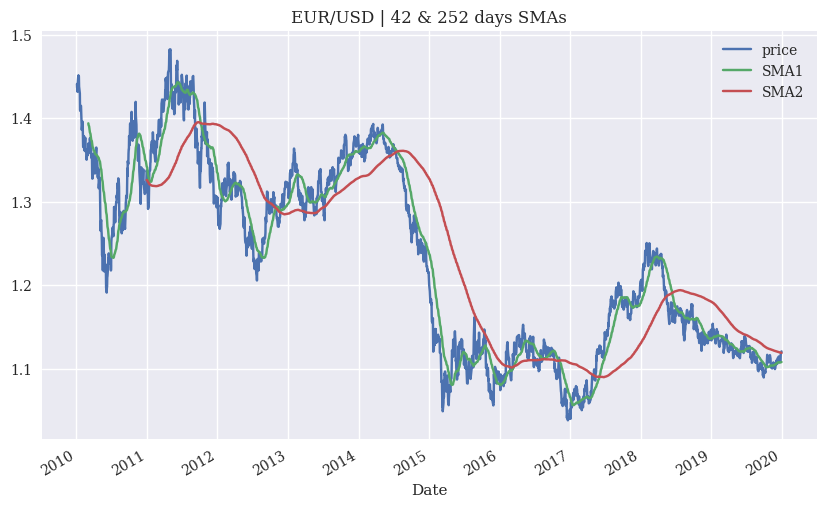

In [84]:
data.plot(title='EUR/USD | 42 & 252 days SMAs',
                   figsize=(10, 6));

In [85]:
import numpy as np
data['position'] = np.where(data['SMA1']>data['SMA2'], 1, -1)

In [86]:
data.dropna(inplace=True)

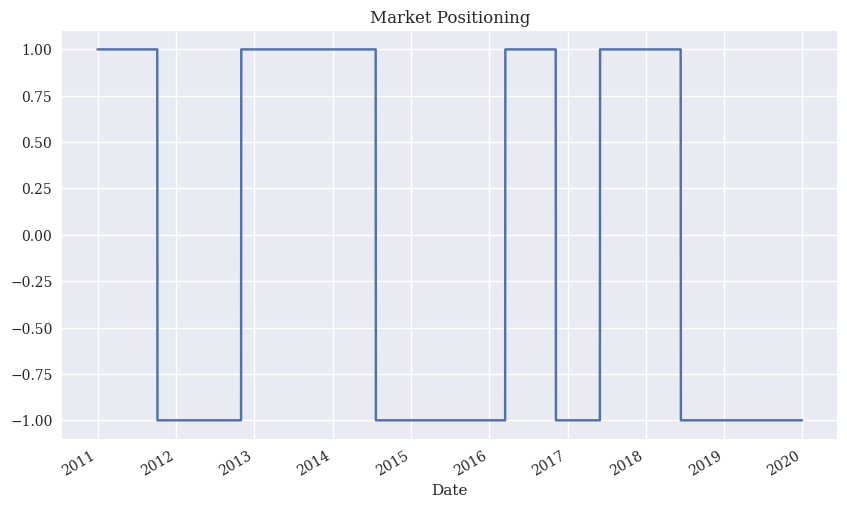

In [87]:
data['position'].plot(ylim=[-1.1, 1.1],
                               title='Market Positioning',
                               figsize=(10, 6));

In [88]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

<Axes: >

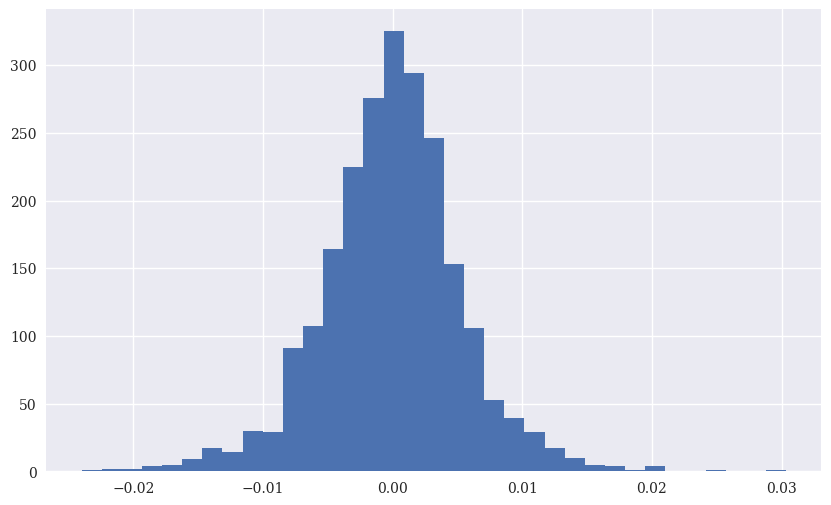

In [89]:
data['returns'].hist(bins=35, figsize=(10,6))

In [90]:
data['strategy'] = data['position'].shift(1)*data['returns']

In [91]:
data[['returns', 'strategy']].sum()


returns    -0.176731
strategy    0.253121
dtype: float64

In [92]:
data[['returns', 'strategy']].sum().apply(np.exp)


returns     0.838006
strategy    1.288039
dtype: float64

In [93]:
data['creturns'] = data['returns'].cumsum().apply(np.exp)
data['cstrategy'] = data['strategy'].cumsum().apply(np.exp)


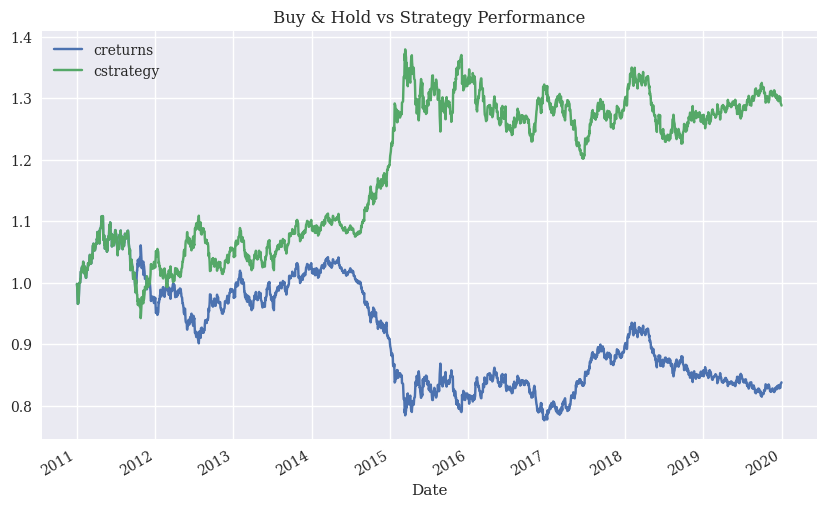

In [94]:
data[['creturns', 'cstrategy']].plot(figsize=(10, 6),
                                     title='Buy & Hold vs Strategy Performance');


In [95]:
data[['returns', 'strategy']].mean()*252

returns    -0.019671
strategy    0.028174
dtype: float64

In [96]:
np.exp(data[['returns','strategy']].mean()*252)-1

returns    -0.019479
strategy    0.028575
dtype: float64

In [97]:
data[['returns','strategy']].std()*252**0.5

returns     0.085414
strategy    0.085405
dtype: float64

In [98]:
(data[['returns','strategy']].apply(np.exp) -1).std()*252**0.5

returns     0.085405
strategy    0.085373
dtype: float64

In [99]:
data['cumret'] = data['strategy'].cumsum().apply(np.exp)

In [100]:
data['cummax'] = data['cumret'].cummax()

<Axes: xlabel='Date'>

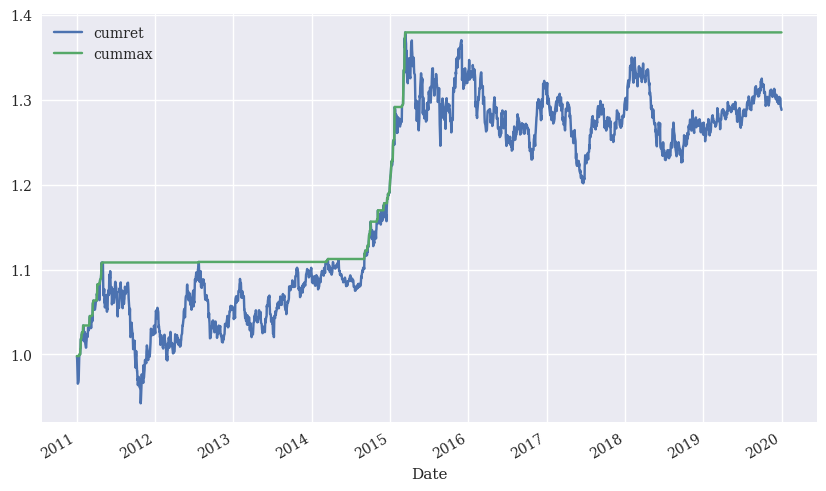

In [101]:
data[['cumret','cummax']].dropna().plot(figsize=(10,6))

In [102]:
drawdown = data['cummax'] - data['cumret']

In [103]:
drawdown.max()

np.float64(0.17779367070195895)

<Axes: xlabel='Date'>

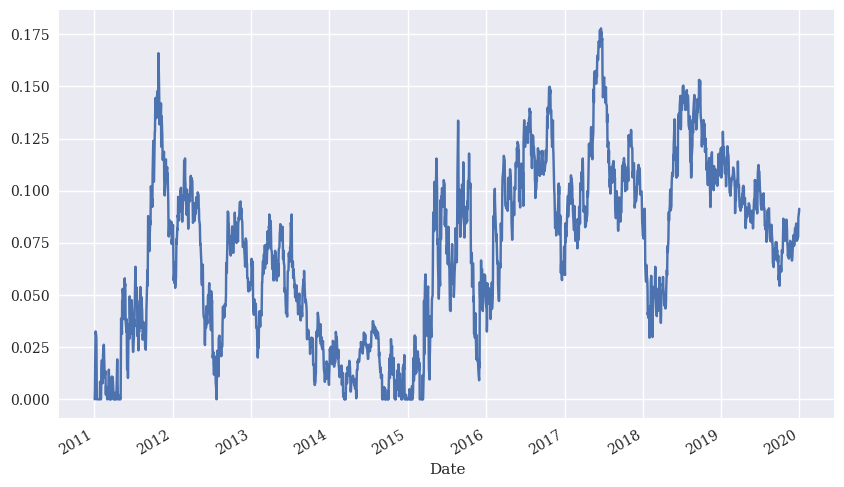

In [111]:
drawdown.dropna().plot(figsize=(10,6))

In [105]:
temp = drawdown[drawdown==0]

In [106]:
periods = (temp.index[1:].to_pydatetime()-
           temp.index[:-1].to_pydatetime())

In [107]:
periods[12:15]

array([datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=10)], dtype=object)

In [108]:
periods.max()

datetime.timedelta(days=596)